### SARIMAX

**Objetivo:** desenvolver um modelo de previsão de PM2.5 utilizando SARIMAX, incorporando variáveis meteorológicas e sazonalidades temporais para previsão das próximas 24 horas.

**Investigar / criar:**

- Definição das variáveis exógenas (temperatura, umidade, vento, etc.)

- Estratégias de tratamento de dados faltantes

- Análise de estacionariedade (ADF)

- Identificação dos parâmetros (p,d,q) e (P,D,Q,m)

- Avaliação de diferentes estratégias de imputação

- Treinamento e validação temporal

- Métricas de desempenho (MAE, RMSE, MAPE)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

In [3]:
# abrindo base de dados para treinamento
data = pd.read_csv("../processed_data/dados_pm25_umi_temp_2016_2019_nan.csv")
data.head()

,time,MP2.5,temperature_2m,relative_humidity_2m
0,2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165
1,2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490
2,2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060
3,2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950
4,2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490


In [4]:
data["time"] = pd.to_datetime(data["time"])
data = data.set_index("time").sort_index()

data.head()

,MP2.5,temperature_2m,relative_humidity_2m
time,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490


In [5]:
y = data["MP2.5"]

In [11]:
# LEWAGON
# We provide you with this method for fast plotting
def plot_autocorrelation(y, d=0, D=0, m=0):
    y = pd.Series(y)
    if D > 0:
        for i in range(D):
            y = y.diff(m)
    if d > 0:
        for i in range(d):
            y = y.diff(1)
    fig = plt.figure(figsize=(20,10))
    ax1 = fig.add_subplot(2,1,1)
    ax2 = fig.add_subplot(2,2,3)
    ax3 = fig.add_subplot(2,2,4)
    ax1.plot(y)
    plot_acf(y, lags = 50, ax=ax2);
    plot_pacf(y, lags=50, method='ywm', ax=ax3, color='r');
    plt.show()

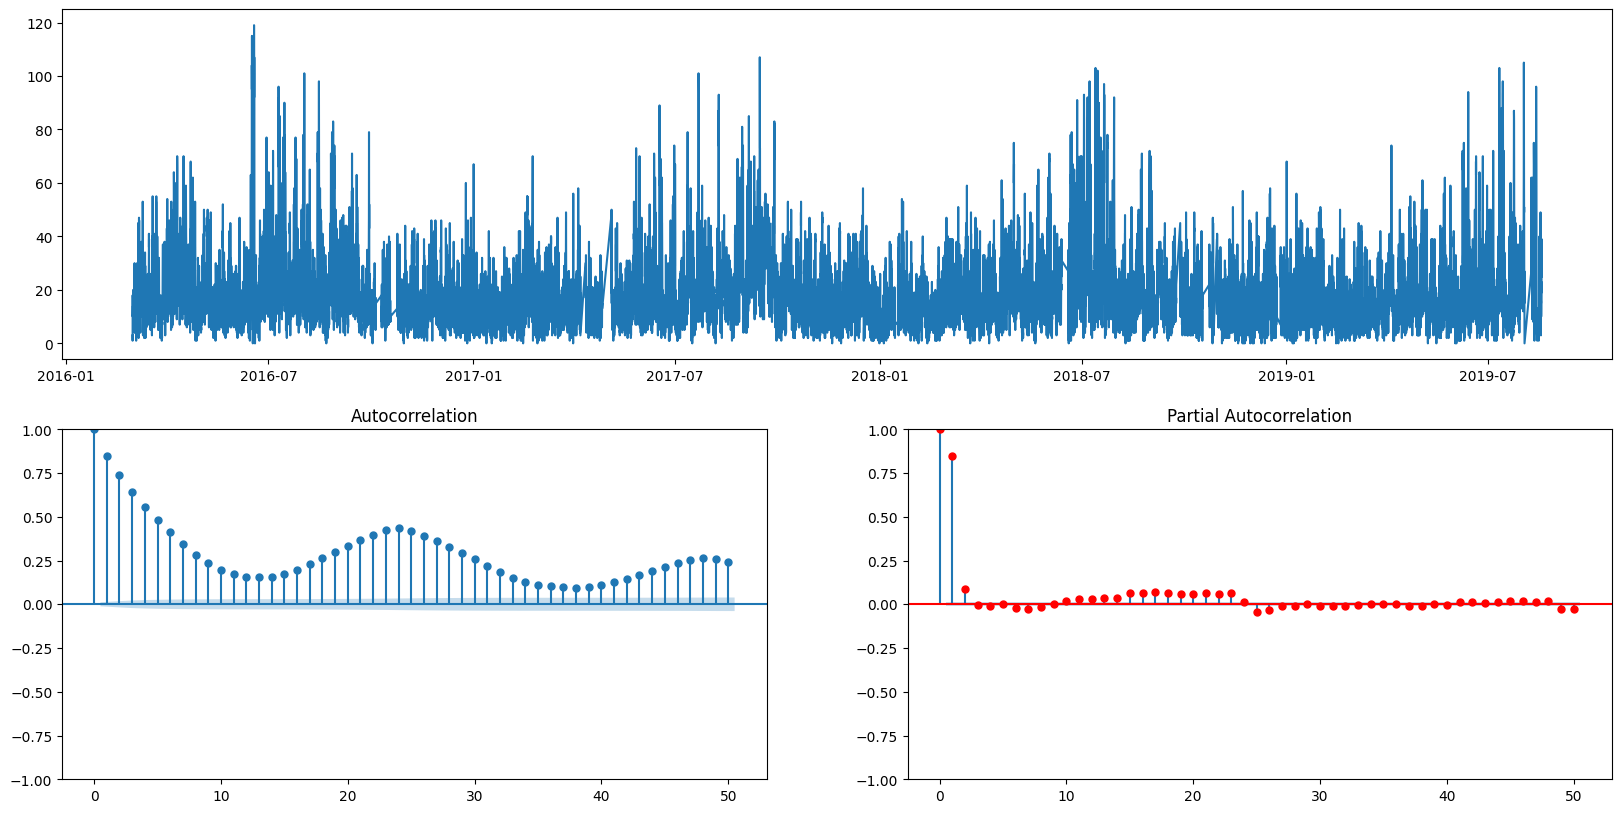

In [12]:
plot_autocorrelation(y.dropna(), d=0, D=0, m=24)

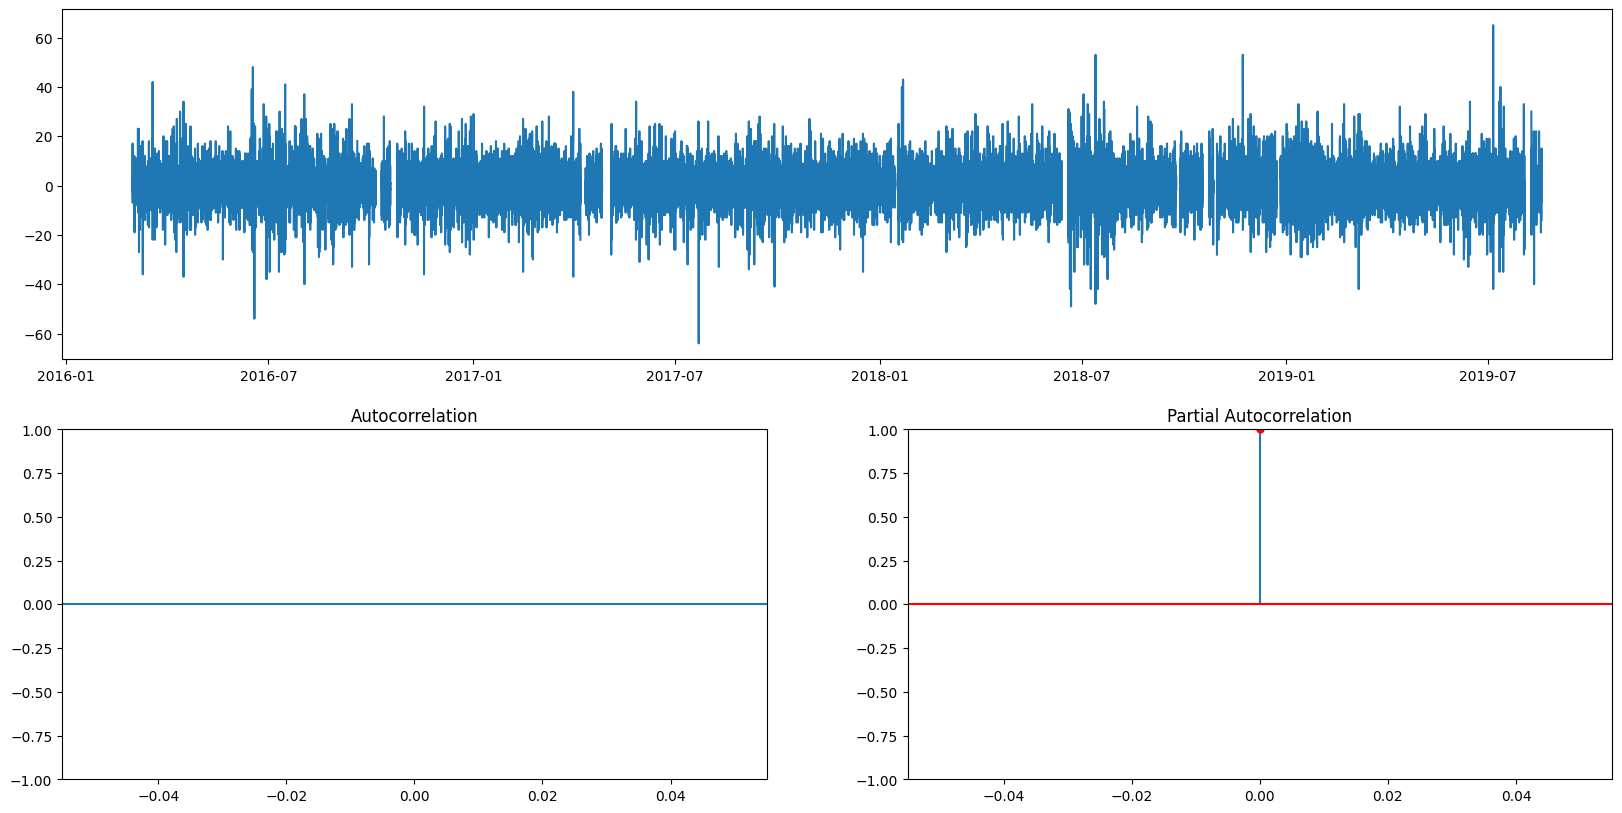

In [13]:
plot_autocorrelation(y, d=1, D=0, m=24)

### Estacionaridade

In [9]:
result = adfuller(y.dropna())

print("ADF statistic:", result[0])
print("p-value:", result[1])

ADF statistic: -15.220753127642597
p-value: 5.489593153239234e-28


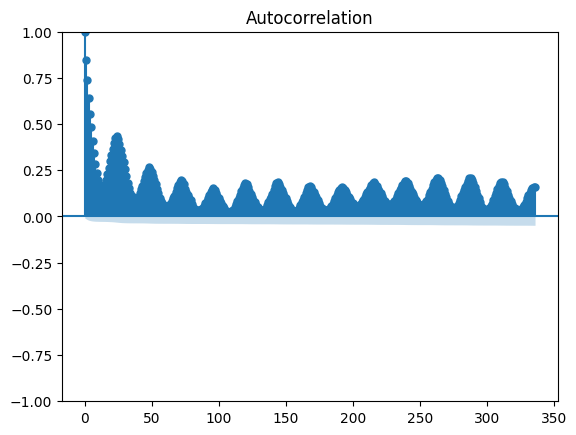

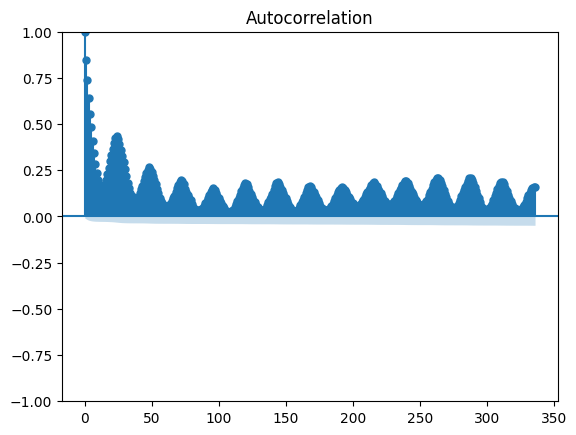

In [10]:
plot_acf(
    y.dropna(),
    lags=24*14
)